<h1>Data Exploratory on Plane Crashes</h1>

I have identified plane accident analysis as the area of interest. With the rapid advancements in aerospace technology, the aviation industry has witnessed a massive growth in terms of efficiency and connectivity but does it come at a price? Even though rigorous safety measures have been strongly implemented and improved over the years, the concern is still there however. In spite of the fact that there were 1.87 accidents per million departures in 2023; a considerable fall of 17.9% from the previous year as stated by the latest ICAO (International Civil Aviation Organization) report [1], isolated incidents can have repercussions on the airline and country involved and on the public perception of air travel in general. This makes it an ongoing challenge that is under constant scrutiny. As such, in order to obtain a comprehensive analysis of historical data that could uncover crucial new insights in the field of aviation safety, a machine learning model can be used. The exploratory aims to use linear regression on plane crash data, specifically for the top 10 crash regions around the world in the current 21st century era, to identify and determine meaningful trends and patterns as well as relationships between various contributing factors. The findings are expected to provide a deeper insight into past incidents which can be purposeful in assisting key stakeholders in the aviation industry, namely, airlines, governments and aviation safety experts as they strategize to mitigate potential risks and formulate enhanced safety measures and guidelines of the most stringent quality, with the goal of reducing the likelihood of future incidents and improving aviation safety as a whole.

In [799]:
import pandas as pd

# Read CSV file
df = pd.read_csv('Crashes_Of_Airplanes.csv')

# Drop columns that are unnecessary or too many missing values
df = df.drop(['Summary', 'cn/In', 'Time', 'Flight #', 'Route'], axis=1)

print(df)

            Date                                           Location  \
0     04/09/1945                                     Kunming, China   
1     04/14/1945                          Morgantown, West Virginia   
2     04/19/1945                              Near Perth, Australia   
3     04/20/1945                                                NaN   
4     04/20/1945                                  Sweetwater, Texas   
...          ...                                                ...   
4562  05/20/2009                             Near Madiun, Indonesia   
4563  05/26/2009                  Near Isiro, DemocratiRepubliCongo   
4564  06/01/2009  AtlantiOcean, 570 miles northeast of Natal, Br...   
4565  06/07/2009       Near Port Hope Simpson, Newfoundland, Canada   
4566  06/08/2009                  State of Arunachal Pradesh, India   

                                 Operator                              Type  \
0     China National Aviation Corporation                      Dougl

The dataset as shown above was obtained from Kaggle [2], a recognised online data science platform with a large community. It consists of 
historical data between 1945 to 2009 that is categorised in a table format with 13 different attributes, namely, the date of crash, crash 
location, aircraft operator, aircraft type, aircraft registration number, number of passengers aboard, number of fatalities on the aircraft,
number of fatalities on the ground, a short summary, aircraft serial number, time of crash, flight number and flight route. I have decided 
not to include the latter 5 attributes as they were either unnecessary for the exploratory or were found to have a large number of missing 
values that would affect the accuracy of the analysis. The dataset is composite, comprising of numerical, date-time and text-based data 
types across a total of 4567 records. It has a relatively small size of 1.39 MB after conversion from the initial xlsx file into an 
appropriate CSV file. The author did not explicitly state the source of data but it most likely originated from various publicly available 
sources online and compiled accordingly. I have also done a random cross-check with a trusted source to ensure reliability, the BAAA (Bureau 
of Aircraft Accidents Archives) [3] and found that both sets of data match.

<h3>Data Preparation</h3>

The following are the steps taken to prepare the data to ensure that it is clean for analysis:
- The dataset is being checked for any duplicate records to avoid discrepancies.
- The dataset is sorted by date in order to extract records across a targeted 10 year span from 1999 to 2009.
- Records that are missing crucial information regarding the aircraft registration number and crash location are removed to avoid
  irregularities in the dataset. In some instances, the plane crash data might be undocumented for reasons pertaining to unregistered or
  missing aircraft or due to classified government or military information.
- The dataset is being checked if there are any other missing values.
- The dataset is converted to 1NF based on splitting values from the "Location" column into atomic forms and regrouping them into 2 new
  columns "Area" and "Region". Normalization helps to reduce data redundancy.

In [804]:
# Check for any duplicated rows
duplicate = df[df.duplicated()]
duplicate

,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground


In [806]:
# Convert "Date" column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Check if the dataset is sorted by date
is_sorted = df['Date'].is_monotonic_increasing
print("Is the data sorted by date?", is_sorted)

# Sort the dataset by date if not sorted
if not is_sorted:
    df = df.sort_values(by='Date', ascending=True).reset_index(drop=True)
    print("Data has been sorted.")

df['Date'] = df['Date'].dt.strftime('%m/%d/%Y')
df

Is the data sorted by date? False
Data has been sorted.


,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground
0,04/09/1945,"Kunming, China",China National Aviation Corporation,Douglas C-47,88,3.0,3.0,0.0
1,04/14/1945,"Morgantown, West Virginia",Pennsylvania Central Airlines,Douglas DC-3,NC25692,20.0,20.0,0.0
2,04/19/1945,"Near Perth, Australia",Military - U.S. Navy,Douglas DC-3,39067,13.0,13.0,0.0
3,04/20/1945,NaN,NaN,Junkers JU-53/3m,D-ANAJ,18.0,18.0,0.0
4,04/20/1945,"Sweetwater, Texas",Military - U.S. Army Air Forces,Douglas C-47-DL,41-18451,25.0,25.0,0.0
...,...,...,...,...,...,...,...,...
4562,05/20/2009,"Near Madiun, Indonesia",Military - Indonesian Air Force,Lockheed C-130 Hercules,A-1325,112.0,98.0,2.0
4563,05/26/2009,"Near Isiro, DemocratiRepubliCongo",Service Air,Antonov An-26,9Q-CSA,4.0,4.0,NaN
4564,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,Airbus A330-203,F-GZCP,228.0,228.0,0.0
4565,06/07/2009,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,Britten-Norman BN-2A-27 Islander,C-FJJR,1.0,1.0,0.0


In [808]:
# Convert "Date" column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Define targeted date range
start_date = pd.to_datetime('1999-06-08')
end_date = pd.to_datetime('2009-06-08')

# Filter rows within the date range
df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

df['Date'] = df['Date'].dt.strftime('%m/%d/%Y')
df = df.reset_index(drop=True)
df

,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground
0,06/09/1999,"Coron, Philippines",PacifiAirways,Britten-Norman BN-2A-21 Islander,RP-C471,1.0,1.0,0.0
1,06/09/1999,"Juneau, Alaska",Air Taxi - Coastal Helicopters Inc.,Eurocopter AS-350BA,N6099S,7.0,7.0,0.0
2,06/17/1999,"Goroka, Papua New Guinea",Airlink,Embraer 110P2 Bandeirante,P2-ALX,17.0,17.0,0.0
3,06/25/1999,"Long Haul Lake, Manatoba, Canada",Blue Water Aviation Services,de Havilland Canada DHC-3 Otter,C-FIFP,2.0,1.0,0.0
4,06/30/1999,"Seraing, Belgium",Nightexpress,Beechcraft 99,D-IBEX,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...
631,05/20/2009,"Near Madiun, Indonesia",Military - Indonesian Air Force,Lockheed C-130 Hercules,A-1325,112.0,98.0,2.0
632,05/26/2009,"Near Isiro, DemocratiRepubliCongo",Service Air,Antonov An-26,9Q-CSA,4.0,4.0,NaN
633,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,Airbus A330-203,F-GZCP,228.0,228.0,0.0
634,06/07/2009,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,Britten-Norman BN-2A-27 Islander,C-FJJR,1.0,1.0,0.0


In [810]:
# Drop rows missing critical info on registration number and crash location
df = df.dropna(subset=['Registration', 'Location'])

df = df.reset_index(drop=True)
df

,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground
0,06/09/1999,"Coron, Philippines",PacifiAirways,Britten-Norman BN-2A-21 Islander,RP-C471,1.0,1.0,0.0
1,06/09/1999,"Juneau, Alaska",Air Taxi - Coastal Helicopters Inc.,Eurocopter AS-350BA,N6099S,7.0,7.0,0.0
2,06/17/1999,"Goroka, Papua New Guinea",Airlink,Embraer 110P2 Bandeirante,P2-ALX,17.0,17.0,0.0
3,06/25/1999,"Long Haul Lake, Manatoba, Canada",Blue Water Aviation Services,de Havilland Canada DHC-3 Otter,C-FIFP,2.0,1.0,0.0
4,06/30/1999,"Seraing, Belgium",Nightexpress,Beechcraft 99,D-IBEX,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...
599,05/03/2009,"Near El Alto de Rubio, Venezuela",Military - Venezuelan Army,Mi-35,EV08114,18.0,18.0,0.0
600,05/20/2009,"Near Madiun, Indonesia",Military - Indonesian Air Force,Lockheed C-130 Hercules,A-1325,112.0,98.0,2.0
601,05/26/2009,"Near Isiro, DemocratiRepubliCongo",Service Air,Antonov An-26,9Q-CSA,4.0,4.0,NaN
602,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,Airbus A330-203,F-GZCP,228.0,228.0,0.0


In [812]:
# Check for any other missing values
null = df[df.isnull().any(axis=1)]
null

,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground
64,03/22/2000,"Herreira, Spain",Military - Ejército del Aire,CASA 212-DE Aviocar 200,TM-12D-73,NaN,NaN,NaN
85,06/23/2000,"Boca Raton, Florida",Universal Jet Aviation,Learjet 55,N220JC,3.0,3.0,NaN
444,04/23/2006,"Near Tersky, Russia",Yug Avia,NaN,RF-30451,5.0,4.0,0.0
488,03/14/2007,"Fazenda Nossa Senhora de Lourdes, Brazil",NaN,Rockwell 500S Shrike Commander,PP-SEC,4.0,4.0,0.0
601,05/26/2009,"Near Isiro, DemocratiRepubliCongo",Service Air,Antonov An-26,9Q-CSA,4.0,4.0,NaN


In [814]:
# Input missing values [4]
df.loc[df.index == 64, ['Aboard', 'Fatalities', 'Ground']] = [7, 7, 0]
df.loc[df.index == 85, 'Ground'] = 1
df.loc[df.index == 444, 'Type'] = 'Antonov An-2R'
df.loc[df.index == 488, 'Operator'] = 'Bahia Taxi Aéreo'
df.loc[df.index == 601, 'Ground'] = 0

In [816]:
# Ensure no missing values remain
null = df[df.isnull().any(axis=1)]
null

,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground


In [818]:
# Locate values with more than 2 components in "Location" column
df_commas = df[df['Location'].str.count(',') > 1]
df_commas

,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground
3,06/25/1999,"Long Haul Lake, Manatoba, Canada",Blue Water Aviation Services,de Havilland Canada DHC-3 Otter,C-FIFP,2.0,1.0,0.0
48,12/24/1999,"Amritsar, India / Kandahar, Afghanistan",Indian Airlines,Airbus A300B2-101,VT-EDW,189.0,1.0,0.0
101,08/14/2000,"Teslin Lake, British Columbia, Canada",RCMP-GRC Air Services,Cessna 208 Caravan I,C-GMPB,2.0,2.0,0.0
110,10/08/2000,"Port Radium, Northwest Territories, Canada",Summit Air Charters,Shorts SC.7 Skyvan 3-100,C-FSDZ,3.0,3.0,0.0
123,12/11/2000,"Near Sumacal, Beni, BO",Servicio Aereo Manchupo,Cessna 206,CP-1721,6.0,6.0,0.0
140,03/24/2001,"Gustavia, St. Barthélémy, French West Indies",Air Caraibes,de Havilland Canada DHC-6 Twin Otter,F-OGES,19.0,19.0,1.0
172,10/08/2001,"Mollet Lake, Quebec, Canada",Air Saint Maurice Inc.,de Havilland DHC-2 Mk 1 Beaver,C-GPUO,7.0,3.0,0.0
178,11/12/2001,"Belle Harbor, Queens, New York",American Airlines,Airbus A-300-605R,N14053,260.0,260.0,5.0
211,04/01/2002,"Near Cairns, QLD, Australia",Air Taxi,Shrike Commander 500S,VH-UJB,4.0,4.0,0.0
214,04/18/2002,"Near Sweers Island, QLD, Australia",Air taxi,Cessna U206A,VH-XGR,6.0,6.0,0.0


In [820]:
# Standardize values to 2 components
df.loc[df.index == 3, 'Location'] = 'Long Haul Lake Manatoba, Canada'	
df.loc[df.index == 48, 'Location'] = 'Amritsar/Kandahar, India/Afghanistan'
df.loc[df.index == 101, 'Location'] = 'Teslin Lake British Columbia, Canada'	
df.loc[df.index == 110, 'Location'] = 'Port Radium Northwest Territories, Canada'	
df.loc[df.index == 123, 'Location'] = 'Near Sumacal Beni, Bolivia'	
df.loc[df.index == 140, 'Location'] = 'Gustavia St. Barthélémy, French West Indies'	
df.loc[df.index == 172, 'Location'] = 'Mollet Lake Quebec, Canada'	
df.loc[df.index == 178, 'Location'] = 'Belle Harbor Queens, New York'	
df.loc[df.index == 211, 'Location'] = 'Near Cairns Queensland, Australia'	
df.loc[df.index == 214, 'Location'] = 'Near Sweers Island Queensland, Australia'	
df.loc[df.index == 224, 'Location'] = 'Oiapoque Amapa, Brazil'	
df.loc[df.index == 232, 'Location'] = 'Off Cromer Norfork, England'	
df.loc[df.index == 244, 'Location'] = 'High Prarie Alberta, Canada'	
df.loc[df.index == 246, 'Location'] = 'Paranapanema Sao Paulo, Brazil'	
df.loc[df.index == 247, 'Location'] = 'Near Natashquan Quebec, Canada'	
df.loc[df.index == 292, 'Location'] = 'Belem Para, Brazil'	
df.loc[df.index == 293, 'Location'] = 'Macaé Rio de Janeiro, Brazil'
df.loc[df.index == 298, 'Location'] = 'Waialeale Kauai, Hawaii'	
df.loc[df.index == 307, 'Location'] = 'Gaspé Quebec, Canada'	
df.loc[df.index == 319, 'Location'] = 'Jellicoe Ontario, Canada'	
df.loc[df.index == 325, 'Location'] = 'Lake Erie off Pelee Island Ontario, Canada'	
df.loc[df.index == 330, 'Location'] = 'Trefoil Island Tasmania, Australia'	
df.loc[df.index == 333, 'Location'] = 'Hamilton Island Queensland, Australia'	
df.loc[df.index == 351, 'Location'] = 'Off Macaé Rio de Janeiro , Brazil'	
df.loc[df.index == 363, 'Location'] = 'Halifax Nova Scotia, Canada'	
df.loc[df.index == 371, 'Location'] = 'Baotou Inner Mongolia, China'	
df.loc[df.index == 383, 'Location'] = 'Tura Siberia, Russia'
df.loc[df.index == 390, 'Location'] = 'Bimin, Papua New Guinea'	
df.loc[df.index == 395, 'Location'] = 'El Embrujo Providencia Island, Colombia'
df.loc[df.index == 402, 'Location'] = 'Lockhart River Queensland, Australia'	
df.loc[df.index == 434, 'Location'] = 'Near Port Alberni British Columbia, Canada'	
df.loc[df.index == 487, 'Location'] = 'Hanea Kauai, Hawaii'	
df.loc[df.index == 502, 'Location'] = 'Muncho Lake British Columbia, Canada'	
df.loc[df.index == 533, 'Location'] = 'Off Macae Rio de Janeiro , Brazil'	
df.loc[df.index == 544, 'Location'] = 'Two Harbors Catalina Island, California'	
df.loc[df.index == 560, 'Location'] = 'North Vancouver Island British Colombia, Canada'
df.loc[df.index == 578, 'Location'] = 'Thormanby Island British Columbia, Canada'	
df.loc[df.index == 602, 'Location'] = '570 miles northeast of Natal Brazil, Atlantic Ocean'	
df.loc[df.index == 603, 'Location'] = 'Near Port Hope Simpson Newfoundland, Canada'	

In [822]:
# Locate values with only 1 component in "Location" column
df_no_commas = df[df['Location'].str.count(',') == 0]
df_no_commas

,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground
308,10/03/2003,Sao Gabriel de Cachoeria,Air taxi - Rumo Notre Air Taxi,EMB 721C Sertanejo,PT-EBK,4.0,4.0,0.0
430,01/02/2006,Near Karkov,Evolga,British Aerospace BAe-125-700A,P4-AOD,3.0,3.0,0.0
449,05/23/2006,Off São Tomé Island,Air São Tomé,de Havilland Canada DHC-6 Twin Otter 300,S9-BAL,4.0,4.0,0.0
582,12/15/2008,Off Turks and Caicos Islands,Alantis Aviation,Britten Norman BN-2A Trislander Mk3,N650LP,12.0,12.0,0.0
583,01/04/2009,Near Houma Louisiana,Petroleum Helicopters Inc,Sikorsky S-76C,N748P,9.0,8.0,0.0


In [824]:
# Standardize values to 2 components
df.loc[df.index == 308, 'Location'] = 'Sao Gabriel de Cachoeria, Brazil'	
df.loc[df.index == 430, 'Location'] = 'Near Karkov, Ukraine'
df.loc[df.index == 449, 'Location'] = 'Off São Tomé Island, São Tomé and Príncipe'	
df.loc[df.index == 582, 'Location'] = 'Off Turks and Caicos Islands, Caribbean Sea'	
df.loc[df.index == 583, 'Location'] = 'Near Houma, Louisiana'

In [826]:
df

,Date,Location,Operator,Type,Registration,Aboard,Fatalities,Ground
0,06/09/1999,"Coron, Philippines",PacifiAirways,Britten-Norman BN-2A-21 Islander,RP-C471,1.0,1.0,0.0
1,06/09/1999,"Juneau, Alaska",Air Taxi - Coastal Helicopters Inc.,Eurocopter AS-350BA,N6099S,7.0,7.0,0.0
2,06/17/1999,"Goroka, Papua New Guinea",Airlink,Embraer 110P2 Bandeirante,P2-ALX,17.0,17.0,0.0
3,06/25/1999,"Long Haul Lake Manatoba, Canada",Blue Water Aviation Services,de Havilland Canada DHC-3 Otter,C-FIFP,2.0,1.0,0.0
4,06/30/1999,"Seraing, Belgium",Nightexpress,Beechcraft 99,D-IBEX,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...
599,05/03/2009,"Near El Alto de Rubio, Venezuela",Military - Venezuelan Army,Mi-35,EV08114,18.0,18.0,0.0
600,05/20/2009,"Near Madiun, Indonesia",Military - Indonesian Air Force,Lockheed C-130 Hercules,A-1325,112.0,98.0,2.0
601,05/26/2009,"Near Isiro, DemocratiRepubliCongo",Service Air,Antonov An-26,9Q-CSA,4.0,4.0,0.0
602,06/01/2009,"570 miles northeast of Natal Brazil, Atlantic ...",Air France,Airbus A330-203,F-GZCP,228.0,228.0,0.0


In [828]:
# Convert to atomic values by extracting area and region from location
df[['Area', 'Region']] = df['Location'].str.extract(r'([^,]+),?\s*(.*)')

# Dataset is now in 1NF
df = df.drop(['Location'], axis=1)
df

,Date,Operator,Type,Registration,Aboard,Fatalities,Ground,Area,Region
0,06/09/1999,PacifiAirways,Britten-Norman BN-2A-21 Islander,RP-C471,1.0,1.0,0.0,Coron,Philippines
1,06/09/1999,Air Taxi - Coastal Helicopters Inc.,Eurocopter AS-350BA,N6099S,7.0,7.0,0.0,Juneau,Alaska
2,06/17/1999,Airlink,Embraer 110P2 Bandeirante,P2-ALX,17.0,17.0,0.0,Goroka,Papua New Guinea
3,06/25/1999,Blue Water Aviation Services,de Havilland Canada DHC-3 Otter,C-FIFP,2.0,1.0,0.0,Long Haul Lake Manatoba,Canada
4,06/30/1999,Nightexpress,Beechcraft 99,D-IBEX,2.0,2.0,0.0,Seraing,Belgium
...,...,...,...,...,...,...,...,...,...
599,05/03/2009,Military - Venezuelan Army,Mi-35,EV08114,18.0,18.0,0.0,Near El Alto de Rubio,Venezuela
600,05/20/2009,Military - Indonesian Air Force,Lockheed C-130 Hercules,A-1325,112.0,98.0,2.0,Near Madiun,Indonesia
601,05/26/2009,Service Air,Antonov An-26,9Q-CSA,4.0,4.0,0.0,Near Isiro,DemocratiRepubliCongo
602,06/01/2009,Air France,Airbus A330-203,F-GZCP,228.0,228.0,0.0,570 miles northeast of Natal Brazil,Atlantic Ocean


<h3>Statistical Analysis</h3>

In [831]:
# Count number of plane crashes for each region and identify the top 10 crash regions
counts = df['Region'].value_counts().head(10)
counts

Region
Brazil                   29
Russia                   25
Canada                   21
Indonesia                20
Venezuela                18
Alaska                   17
Colombia                 16
Mexico                   15
California               12
DemocratiRepubliCongo    11
Name: count, dtype: int64

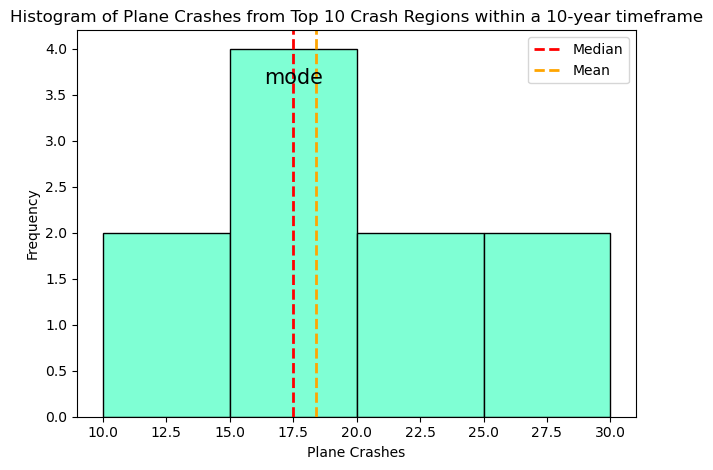

mode = (15, 20]
median = 17.5
mean = 18.4


In [833]:
import matplotlib.pyplot as plt
import numpy as np

# Create bins for the counts
bins = np.arange(10, 31, 5)

# Plot the histogram
plt.hist(counts, bins=bins, color='aquamarine', edgecolor='black')

# Calculate mode
mode = pd.cut(counts, bins).mode()[0]
# Annotate mode on the plot
plt.annotate('mode', xy=(mode.mid, plt.ylim()[1] * 0.9), 
             xytext=(mode.mid, plt.ylim()[1] * 0.85),
             horizontalalignment='center', verticalalignment='bottom', fontsize=15)

# Calculate median
median = counts.median()
# Plot the median as a vertical line
plt.axvline(median, color='red', linestyle='dashed', linewidth=2, label=f'Median')

# Calculate mean
mean = counts.mean()
# Plot the mean as a vertical line
plt.axvline(mean, color='orange', linestyle='dashed', linewidth=2, label=f'Mean')

# Set title, labels and legend
plt.title('Histogram of Plane Crashes from Top 10 Crash Regions within a 10-year timeframe')
plt.xlabel('Plane Crashes')
plt.ylabel('Frequency')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

# Print mode, median and mean values
print(f"mode = {mode}")
print(f"median = {median}")
print(f"mean = {mean}")

The above histogram shows the number of occurences of plane crashes from the top 10 regions that suffered the most crashes within the
targeted timeframe, where the x-axis represents the number of plane crashes while the y-axis represents the frequency of regions that
fall into each given range of plane crashes. The most common number of plane crashes (mode) is deduced to be between 15 to 20 from the
highest bar in the diagram. The mean and median number of plane crashes are denoted by the red and yellow line respectively. Both have
close values and fall in the mode bar, indicating a symmetrical distribution. The visualization is useful in determining the 
distribution pattern of the data based on the mean, median and mode.

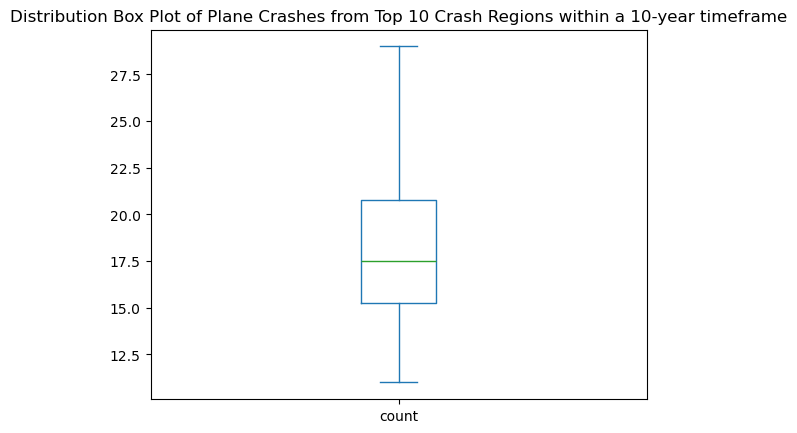

count    10.000000
mean     18.400000
std       5.581716
min      11.000000
25%      15.250000
50%      17.500000
75%      20.750000
max      29.000000
Name: count, dtype: float64
variance: 31.15555555555556
range: 18
IQR: 5.5


In [836]:
# Plot the box plot
ax = counts.plot.box()

# Set title
ax.set_title('Distribution Box Plot of Plane Crashes from Top 10 Crash Regions within a 10-year timeframe')

# Show the plot
plt.show()

# Generate and print statistics of counts
print(counts.describe())

# Calculate and print variance value
variance = counts.var()
print(f"variance: {variance}")

# Calculate and print range value
range = counts.max() - counts.min()
print(f"range: {range}")

# Calculate and print IQR value
Q1 = counts.quantile(0.25)
Q3 = counts.quantile(0.75)
IQR = Q3 - Q1
print(f"IQR: {IQR}")

The above box plot can also be used to show the distribution of plane crashes from the top 10 regions that suffered the most crashes 
within the targeted timeframe where the box represents the IQR of the number of plane crashes while the top and bottom end points 
represent the 1st and 3rd quartiles respectively. The line in the box denotes the median number of plane crashes. This visualization
helps to identify the distribution of the data based on the IQR and median.

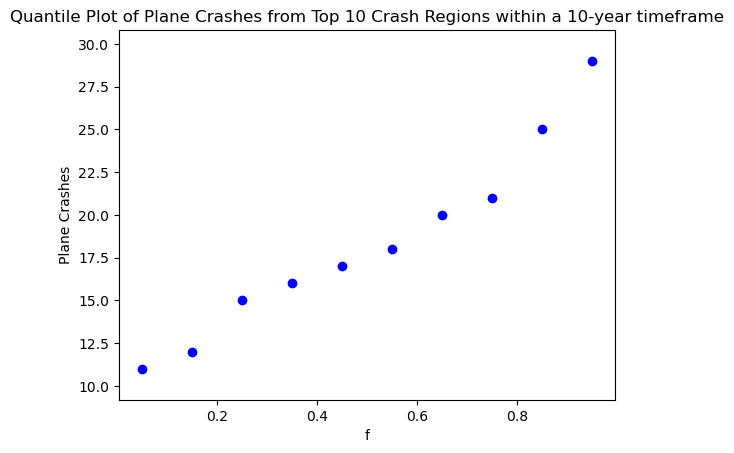

In [839]:
# Calculate normalised f-values
def fvalue(var):
    i = np.arange(1, len(var) + 1)
    return (i - 0.5) / len(var)

# Create the quantile scatter plot
fig, ax = plt.subplots(1)
ax.scatter(fvalue(counts), np.sort(counts), color="blue")  

# Set padding and limits
padding = (max(counts) - min(counts)) * 0.1
ax.set_ylim(min(counts) - padding, max(counts) + padding) 

# Set title and labels
ax.set_title('Quantile Plot of Plane Crashes from Top 10 Crash Regions within a 10-year timeframe')
ax.set_xlabel('f')
ax.set_ylabel('Plane Crashes')

# Show the plot
plt.show()

The above quantile plot can also be used to show the distribution of plane crashes from the top 10 regions that suffered the most 
crashes within the targeted timeframe where the x-axis represents the normalized scale of quantiles (f) while the y-axis represents 
the number of plane crashes. From the diagram, the data points appear to have a positive linear relationship; the number of plane 
crashes increases as f increases, indicating a uniform distribution. This visualization helps to identify the distribution of the 
data points based on the nature of the trend.

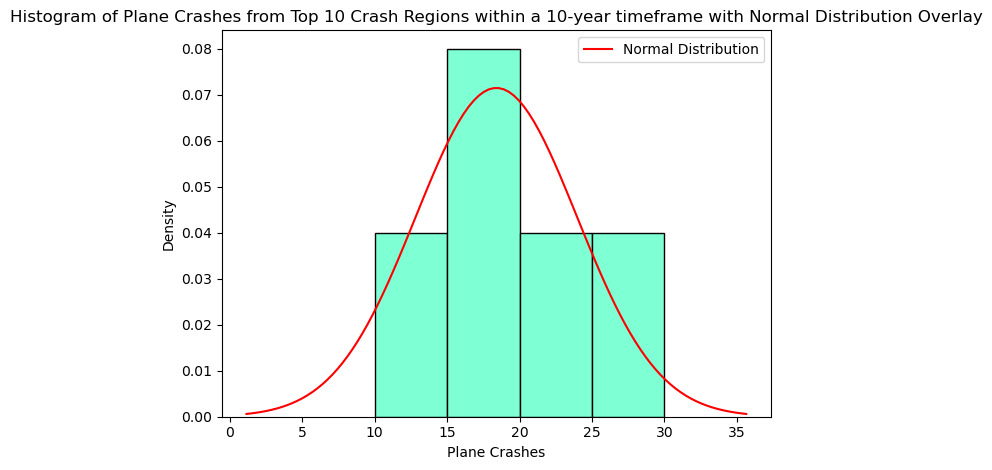

skewness: 0.62
kurtosis: 0.03


In [842]:
from scipy.stats import norm

# Create bins for the counts
bins = np.arange(10, 31, 5)

# Plot the histogram
plt.hist(counts, density=True, bins=bins, color='aquamarine', edgecolor='black')

# Generate quantiles
std = counts.std()
quantiles = np.linspace(norm.ppf(0.001, loc=mean, scale=std), norm.ppf(0.999, loc=mean, scale=std), 100)

# Plot the normal distribution
plt.plot(quantiles, norm.pdf(quantiles, loc=mean, scale=std), color='red', label='Normal Distribution')

# Add title, labels and legend
plt.title('Histogram of Plane Crashes from Top 10 Crash Regions within a 10-year timeframe with Normal Distribution Overlay')
plt.xlabel('Plane Crashes')
plt.ylabel('Density')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

# Calculate and print skew value
skew_value = counts.skew().round(2)
print(f"skewness: {skew_value}")

# Calculate and print kurtosis value
kurtosis_value = counts.kurtosis().round(2)
print(f"kurtosis: {kurtosis_value}")

The above histogram is a modified version of the histogram plotted earlier. The y-axis now represents the density of regions that fall
into each given range of plane crashes. Using density instead of frequency helps to normalize the histogram as this can be displayed 
using a normal distribution curve. The histogram has a positive skewness value that indicates a right-skewed distribution and a kurtosis
value that is close to zero that indicates a normal spread of data points. In my opinion, this is the best technique of visualization as 
the implementation of a normal distribution curve emphasises the shape of data distribution, making the comparison of data points to 
normality that can help to identify patterns to be more convenient.

<h3>Linear Regression</h3>

In [846]:
# Filter the top 10 crash regions
top_regions = counts.index.tolist()
filtered_df = df[df['Region'].isin(top_regions)]
filtered_df = filtered_df.copy()

# Convert "Date" column to datetime format and extract year
filtered_df.loc[:, 'Year'] = pd.to_datetime(filtered_df['Date']).dt.year

# Count number of plane crashes by year for the top 10 crash regions within targeted year range
yearly_counts = filtered_df['Year'].value_counts().sort_index()
yearly_counts = yearly_counts[(yearly_counts.index > 1999) & (yearly_counts.index < 2009)]

print(yearly_counts)

Year
2000    16
2001    25
2002    19
2003    19
2004    22
2005    15
2006    13
2007    18
2008    15
Name: count, dtype: int64


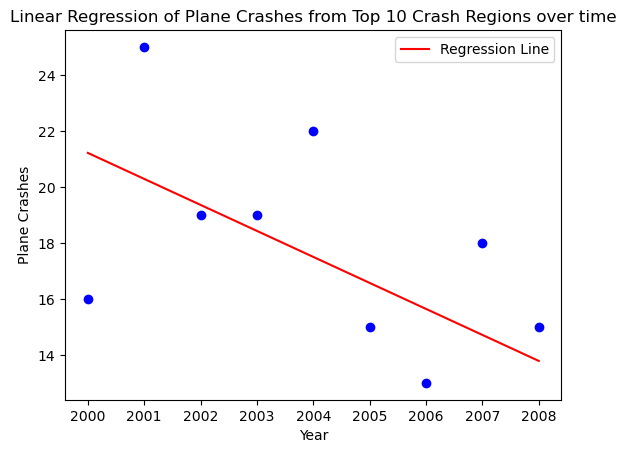

R² Score: -1.726757369614453


In [848]:
from sklearn import linear_model
from sklearn.metrics import r2_score

# Define X and y
X = yearly_counts.index.values.reshape(-1, 1)  
y = yearly_counts.values  

# Use all but the last 2 years for training
X_train = X[:-2] 
y_train = y[:-2] 
# Use the last 2 years for testing
X_test = X[-2:]   
y_test = y[-2:]   

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using training sets
regr.fit(X_train, y_train)

# Make predictions using testing set
y_pred = regr.predict(X_test)

# Create the scatter plot
plt.scatter(X, y, color="blue")

# Plot the regression line
plt.plot(X, regr.predict(X), color="red", label="Regression Line")

# Add title, labels and legend
plt.title("Linear Regression of Plane Crashes from Top 10 Crash Regions over time")
plt.xlabel("Year")
plt.ylabel("Plane Crashes")
plt.legend()

# Show the plot
plt.show()

# Calculate and print R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

The linear regression model takes into account the years as the independent variable and the number of plane crashes as the dependent 
variable with the aim of analyzing the trend of plane crashes over time for the top 10 regions. Only records for whole years within 
the previously extracted timeframe are used in order to calculate the total number of plane crashes by year. Using a time-based
feature like year allows for a time-series analysis which can be used to identify any trends and predict outcomes in the identified 
high risk regions. This can prove essential in reshaping strategies to reduce the probability of future incidents and contribute 
towards improving aviation safety in general.

The R² score of the model is however calculated to have a negative value. This implies that the model is performing worse than 
expected and it is not suitable to make predictions. Outliers that fall outside of the IQR can be removed to rectify the issue.

In [852]:
# Calculate the 1st and 3rd quartiles
Q1 = yearly_counts.quantile(0.25)
Q3 = yearly_counts.quantile(0.75)

# Define the lower and upper bounds 
lower_bound = Q1 
upper_bound = Q3

# Set the lower and upper bounds to remove outliers
filtered_yearly_counts = yearly_counts[(yearly_counts >= lower_bound) & (yearly_counts <= upper_bound)]

print(filtered_yearly_counts)

Year
2000    16
2002    19
2003    19
2005    15
2007    18
2008    15
Name: count, dtype: int64


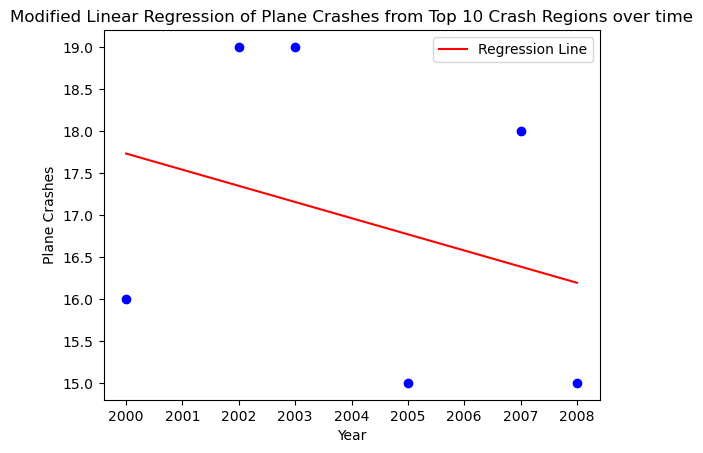

R² Score: 0.10420775805390015
cross-validation R² Scores: [-1.87893006  0.10841578  0.10420776]


In [854]:
from sklearn.model_selection import cross_val_score

# Define X and y
X = filtered_yearly_counts.index.values.reshape(-1, 1)  
y = filtered_yearly_counts.values  

# Use all but the last 2 years for training
X_train = X[:-2]  
y_train = y[:-2] 
# Use the last 2 years for testing
X_test = X[-2:]   
y_test = y[-2:]   

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X_train, y_train)

# Make predictions using the testing set
y_pred = regr.predict(X_test)

# Create the scatter plot
plt.scatter(X, y, color="blue")

# Plot the regression line
plt.plot(X, regr.predict(X), color="red", label="Regression Line")

# Add title, labels and legend
plt.title("Modified Linear Regression of Plane Crashes from Top 10 Crash Regions over time")
plt.xlabel("Year")
plt.ylabel("Plane Crashes")
plt.legend()

# Show the plot
plt.show()

# Calculate and print R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

# Perform and print cross validation results
cv_scores = cross_val_score(regr, X, y, cv=3)  
print(f"cross-validation R² Scores: {cv_scores}")

The R² score is now positive which indicates that the model has shown an improvement in performance. To provide a more 
reliable evaluation of the model's performance, cross validation can be utilized, in this case, a 3-fold cross-validation.
2 out of the 3 validation results were found to be in close proximity with the actual R² Score which implies that the 
model's performance is relatively consistent across different data points.

The R² score is however low and this means that even though the model is learning, it has a weak performance and there is
significant potential to improve it through feature engineering. Instead of the number of plane crashes, a new feature, the 
number of passengers involved in plane crashes will be used and analysed with time. This is so as the number of passengers 
could potentially be a major factor in plane crashes and offer a more relevant and meaningful insight upon analysis.

In [858]:
# Count number of passengers involved in plane crashes by year for the top 10 crash regions within targeted year range
yearly_passengers = filtered_df.groupby('Year')['Aboard'].sum()
yearly_passengers = yearly_passengers[(yearly_passengers.index > 1999) & (yearly_passengers.index < 2009)]

print(yearly_passengers)

Year
2000    279.0
2001    538.0
2002    328.0
2003    126.0
2004    417.0
2005    711.0
2006    568.0
2007    575.0
2008    264.0
Name: Aboard, dtype: float64


In [860]:
# Calculate the 1st and 3rd quartiles
Q1 = yearly_passengers.quantile(0.25)
Q3 = yearly_passengers.quantile(0.75)

# Define the lower and upper bounds
lower_bound = Q1 
upper_bound = Q3 

# Set the lower and upper bounds to remove outliers
filtered_yearly_passengers = yearly_passengers[(yearly_passengers >= lower_bound) & (yearly_passengers <= upper_bound)]

print(filtered_yearly_passengers)

Year
2000    279.0
2001    538.0
2002    328.0
2004    417.0
2006    568.0
Name: Aboard, dtype: float64


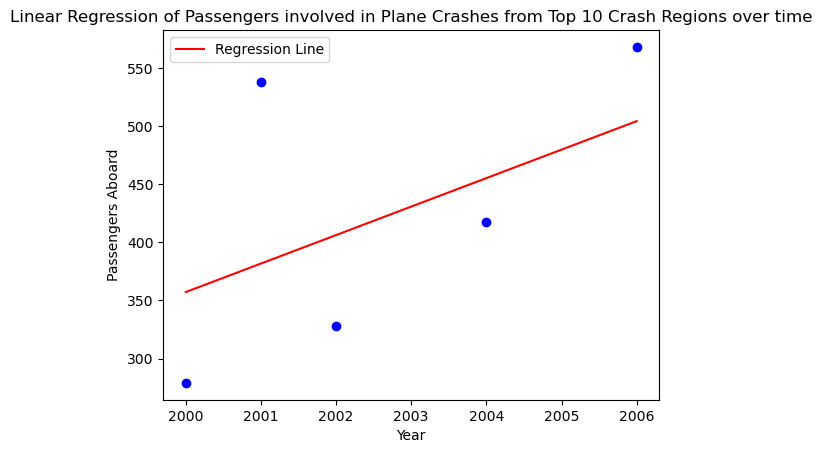

R² Score: 0.5148117285304141


In [862]:
# Define X and y
X = filtered_yearly_passengers.index.values.reshape(-1, 1)  
y = filtered_yearly_passengers.values 

# Use all but the last 2 years for training
X_train = X[:-2]  
y_train = y[:-2] 
# Use the last 2 years for testing
X_test = X[-2:]  
y_test = y[-2:]   

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X_train, y_train)

# Make predictions using the testing set
y_pred = regr.predict(X_test)

# Create the scatter plot
plt.scatter(X, y, color="blue")

# Plot the regression line
plt.plot(X, regr.predict(X), color="red", label="Regression Line")

# Add title, labels and legend
plt.title("Linear Regression of Passengers involved in Plane Crashes from Top 10 Crash Regions over time")
plt.xlabel("Year")
plt.ylabel("Passengers Aboard")
plt.legend()

# Show the plot
plt.show()

# Calculate and print R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

The R² score has improved once again which indicates that the model has shown another improvement in performance. The 
model can be highly beneficial to key stakeholders as it provides them with a better understanding of specific factors, 
in this case, the number of passengers involved in plane crashes, over time through identifying trends that can assist 
in decision and policy making. This includes optimizing flight schedules and improving passenger management, especially 
for high-risk regions and during peak periods. As such, this fulfills the initial objective of reducing the likelihood 
of future incidents and enhancing overall operational safety in the aviation industry. The solution can be transferable 
to other domains if they share a similar nature whereby certain factors play a role in impacting the outcome. An example 
would be predicting manufacturing defects of a good based on production numbers in the manufacturing domain. However, if
the relationships between the independent and dependent variables are different, the model may not be compatible. Feature
engineering or an alternative machine learning model will be required to analyse the data instead.

<h3>Appendix</h3>

[1] https://www.icao.int/safety/Documents/ICAO_SR_2024.pdfphp


[2] https://www.kaggle.com/datasets/yashdixit24/crashes-of-airplanes

[3] https://www.baaa-acro.com/

[4] 64 - https://www.baaa-acro.com/aircraft/casa-212-aviocar?page=4
    85 - https://www.baaa-acro.com/operator/universal-jet-aviation
    444 - https://asn.flightsafety.org/asndb/322201
    488 - https://www.baaa-acro.com/aircraft/rockwell-shrike-commander-500?page=1
    601 - https://www.aeroport-kinshasa.com/en/blacklist_crash_congo.php